In [38]:
!pip install pynwb

In [39]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x138705781209904
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [40]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x138705514194000
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [41]:
import numpy as np

def bin_all_units(nwb_file, bin_size=0.05):
    """
    Standardized function to convert NWB unit spike times into a population matrix.
    """
    units = nwb_file.units
    num_units = len(units)
    
    # Use a fixed maximum time if you need to compare across different files/notebooks
    # Otherwise, ensure the end_time calculation is consistent
    global_max_time = np.max([np.max(spikes) for spikes in units['spike_times'] if len(spikes) > 0])
    
    bins = np.arange(0, global_max_time + bin_size, bin_size)
    num_bins = len(bins) - 1
    
    population_matrix = np.zeros((num_bins, num_units))
    
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

In [42]:
# Re-run the binning with the new 0.05 setting
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.05)

print(f"New matrix shape (Bins x Units): {train_matrix.shape}")

New matrix shape (Bins x Units): (96187, 54)


In [43]:
# Convert the trials table to a pandas DataFrame
trials_df = nwbfile.trials.to_dataframe()

# Display the column names and the first few rows
print("Columns in trials table:", trials_df.columns)
print(trials_df.head())

Columns in trials table: Index(['start_time', 'stop_time', 'fix_on_time', 'fix_time', 'target_on_time',
       'ready_time', 'set_time', 'go_time', 'target_acq_time', 'reward_time',
       'bad_time', 'is_short', 'is_eye', 'theta', 'ts', 'tp', 'fix_time_dur',
       'target_time_dur', 'iti', 'reward_dur', 'is_outlier', 'split'],
      dtype='object')
    start_time  stop_time  fix_on_time  fix_time  target_on_time  ready_time  \
id                                                                             
0       0.5160     3.4825       0.5160    0.5500          1.0835      1.7835   
1       3.9995     7.1495       3.9995    4.0335          4.6335      5.2670   
2       7.6660    11.7995       7.6660    7.7000          8.6000      9.5500   
3      12.3165    12.3830      12.3165   12.3505             NaN         NaN   
4      13.9160    17.7160      13.9160   14.0670         14.9335     15.2335   

    set_time  go_time  target_acq_time  reward_time  ...  is_eye  theta  \
id         

In [44]:
def get_psth_data(matrix, event_times, bin_size=0.05, window_before=0.5, window_after=1.0):
    # This calculation now uses the correct bin_size of 0.05
    event_bins = (event_times / bin_size).astype(int)
    
    bins_before = int(window_before / bin_size)
    bins_after = int(window_after / bin_size)
    
    snippets = []
    for b in event_bins:
        if b - bins_before >= 0 and b + bins_after < matrix.shape[0]:
            snippets.append(matrix[b - bins_before : b + bins_after, :])
            
    return np.array(snippets)

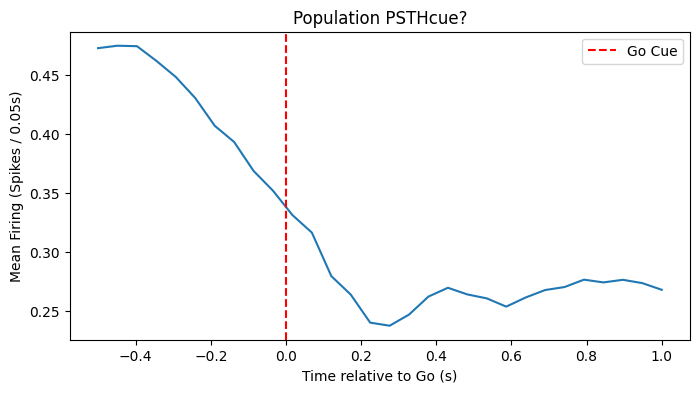

In [45]:
import matplotlib.pyplot as plt

# Extract new snippets
valid_trials = trials_df.dropna(subset=['go_time'])
go_times = valid_trials['go_time'].values
psth_snippets = get_psth_data(train_matrix, go_times, bin_size=0.05)

# Calculate mean
mean_psth = np.mean(psth_snippets, axis=(0, 2))

# Plot
time_axis = np.linspace(-0.5, 1.0, len(mean_psth))
plt.figure(figsize=(8, 4))
plt.plot(time_axis, mean_psth)
plt.axvline(0, color='red', linestyle='--', label='Go Cue')
plt.xlabel('Time relative to Go (s)')
plt.ylabel('Mean Firing (Spikes / 0.05s)')
plt.title('Population PSTHcue?')
plt.legend()
plt.show()

Text(0, 0.5, 'Unit Index')

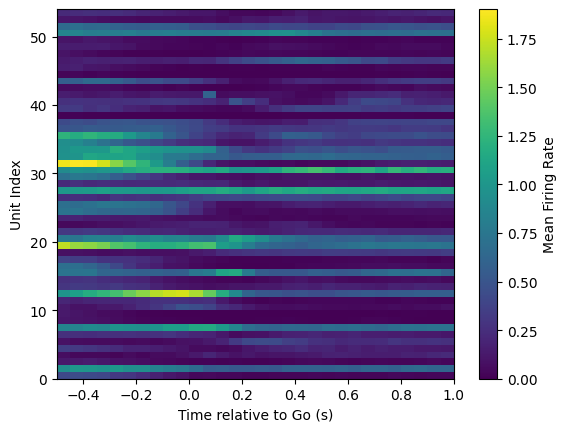

In [46]:
plt.imshow(np.mean(psth_snippets, axis=0).T, aspect='auto', origin='lower', extent=[-0.5, 1.0, 0, 54])
plt.colorbar(label='Mean Firing Rate')
plt.xlabel('Time relative to Go (s)')
plt.ylabel('Unit Index')

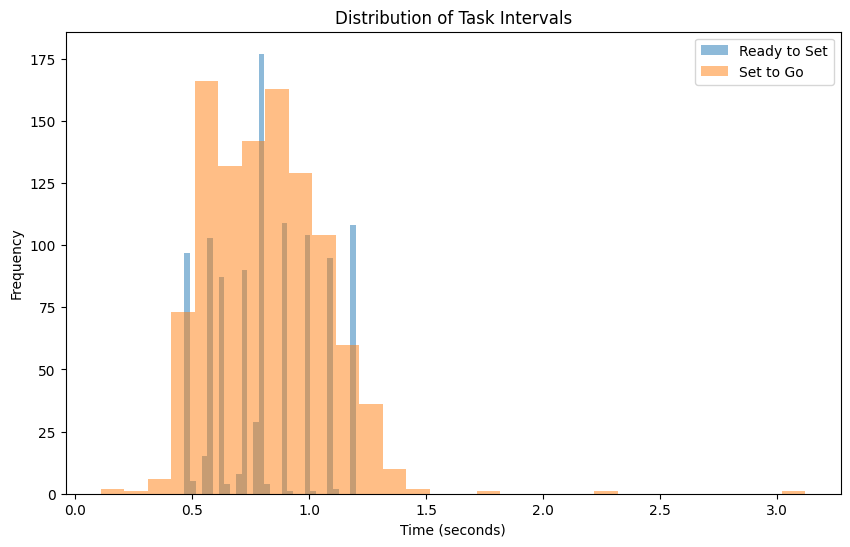

In [48]:
# Calculate the intervals
trials_df['ready_to_set'] = trials_df['set_time'] - trials_df['ready_time']
trials_df['set_to_go'] = trials_df['go_time'] - trials_df['set_time']

# Now your plotting code will work
plt.figure(figsize=(10, 6))
plt.hist(trials_df['ready_to_set'].dropna(), bins=30, alpha=0.5, label='Ready to Set')
plt.hist(trials_df['set_to_go'].dropna(), bins=30, alpha=0.5, label='Set to Go')

plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Task Intervals')
plt.legend()
plt.show()

In [49]:
from scipy import stats

# 1. Start with your train_matrix (from your bin_all_units function)
# 2. Z-score each neuron individually to normalize firing rates
# This ensures that neurons with high firing rates don't dominate the PCA/manifold
zscored_matrix = stats.zscore(train_matrix, axis=0)

# 3. Handle potential NaNs (if any neuron has zero variance/firing)
zscored_matrix = np.nan_to_num(zscored_matrix)

print(f"Standardized matrix shape: {zscored_matrix.shape}")

Standardized matrix shape: (96187, 54)


In [51]:
from sklearn.decomposition import PCA

# 1. Initialize PCA (e.g., to 3 components)
pca = PCA(n_components=3)

# 2. Fit the PCA model to your standardized (z-scored) data
pca.fit(zscored_matrix)

# 3. Now the code in your plotting cell will work
# (Continue with your existing logic)

PCA(n_components=3)

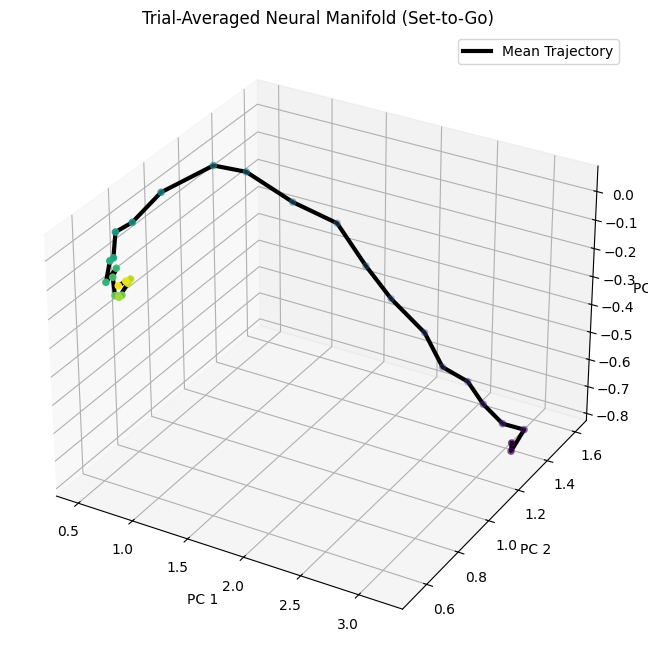

In [52]:
n_trials, n_bins, n_units = psth_snippets.shape
snippets_reshaped = psth_snippets.reshape(-1, n_units)
latent_snippets = pca.transform(snippets_reshaped)
latent_snippets = latent_snippets.reshape(n_trials, n_bins, 3)

# 2. Calculate the mean trajectory across all trials
mean_trajectory = np.mean(latent_snippets, axis=0)

# 3. Plot the result
plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')

# Plot the average trajectory
ax.plot3D(mean_trajectory[:, 0], mean_trajectory[:, 1], mean_trajectory[:, 2], 
          color='black', lw=3, label='Mean Trajectory')

# Scatter points to show the progression of time
ax.scatter(mean_trajectory[:, 0], mean_trajectory[:, 1], mean_trajectory[:, 2], 
           c=np.linspace(0, 1, n_bins), cmap='viridis')

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Trial-Averaged Neural Manifold (Set-to-Go)')
plt.legend()
plt.show()

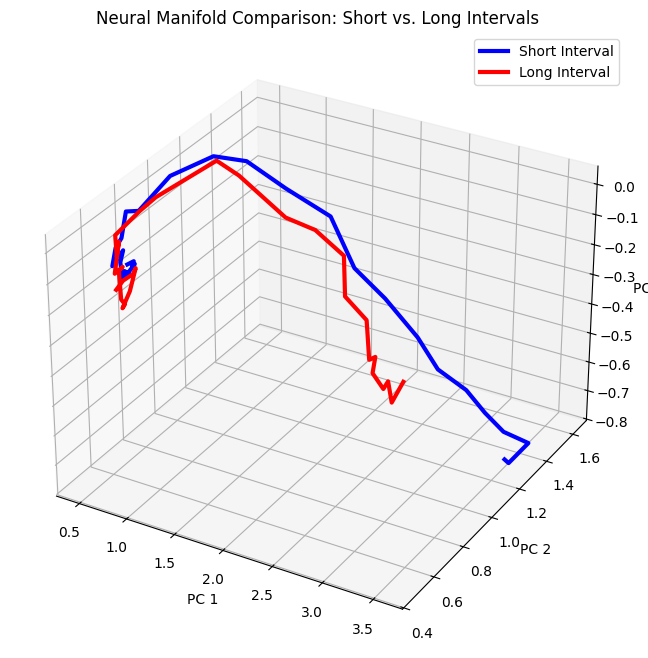

In [53]:
num_actual_trials = latent_snippets.shape[0]

# 2. Filter the valid_trials to match the number of trials actually returned by get_psth_data
# We take the first 'num_actual_trials' from your valid_trials dataframe
matched_trials = valid_trials.iloc[:num_actual_trials]

# 3. Create the indices again based on this matched data
short_trials_idx = np.where(matched_trials['ts'] < 1000)[0]
long_trials_idx = np.where(matched_trials['ts'] >= 1000)[0]

# 4. Extract snippets (This should now work without an IndexError)
short_snippets = latent_snippets[short_trials_idx]
long_snippets = latent_snippets[long_trials_idx]

# Now proceed with your plotting...
mean_short = np.mean(short_snippets, axis=0)
mean_long = np.mean(long_snippets, axis=0)

plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.plot3D(mean_short[:, 0], mean_short[:, 1], mean_short[:, 2], color='blue', lw=3, label='Short Interval')
ax.plot3D(mean_long[:, 0], mean_long[:, 1], mean_long[:, 2], color='red', lw=3, label='Long Interval')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Neural Manifold Comparison: Short vs. Long Intervals')
plt.legend()
plt.show()

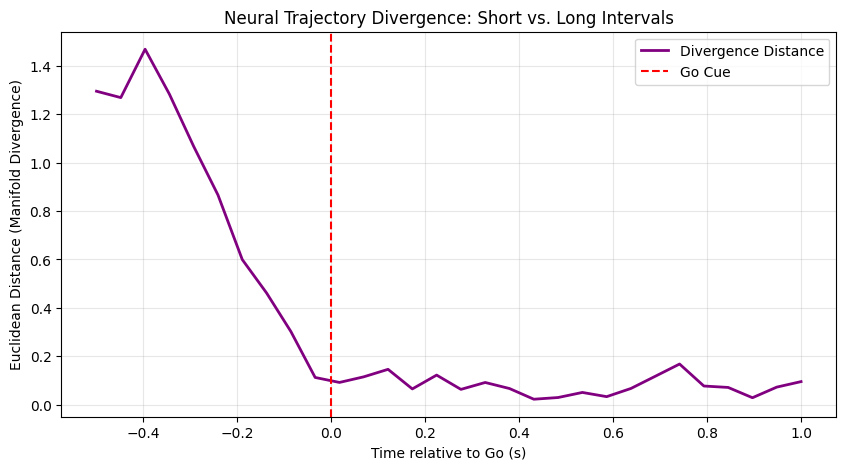

In [54]:
# 1. Calculate the Euclidean distance between the two trajectories at each time point
# This creates a 1D array representing the 'gap' between the two trajectories over time
divergence = np.linalg.norm(mean_short - mean_long, axis=1)

# 2. Plot the divergence over time
# Note: Ensure 'time_axis' is defined (it was defined in your earlier PSTH plot)
time_axis = np.linspace(-0.5, 1.0, len(divergence))

plt.figure(figsize=(10, 5))
plt.plot(time_axis, divergence, color='purple', lw=2, label='Divergence Distance')
plt.axvline(0, color='red', linestyle='--', label='Go Cue')
plt.xlabel('Time relative to Go (s)')
plt.ylabel('Euclidean Distance (Manifold Divergence)')
plt.title('Neural Trajectory Divergence: Short vs. Long Intervals')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()